## Network recovery via partial correlation

- load the ecoli70 Bayesian network from pgmpy
- moralize the DAG to get the undirected conditional dependence graph
  (each pair of co-parents gets connected, then directions are dropped)
- encode that moral graph as the sparsity pattern of a Gaussian precision matrix
- simulate multivariate-normal data from the implied covariance
- recover the network with an FDR-controlled partial-correlation test:
  Fisher z-transform each sample partial correlation, derive a p-value
  under the zero-partial-correlation null, then apply Benjamini-Hochberg
  correction across all pairs
- compare the recovered edges to the true moral graph

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pgmpy.utils import get_example_model
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

from bettercode.utils import save_fig

IMAGE_DIR = Path('../../latex/figures')
CHAPTER = 9

# Load the ecoli70 DAG and moralize it to obtain the conditional dependence graph.
ecoli_model = get_example_model('ecoli70')
moral_graph = ecoli_model.moralize()
nodes = sorted(ecoli_model.nodes())
true_edges = {tuple(sorted((u, v))) for u, v in moral_graph.edges()}
print(f'{len(nodes)} nodes, {len(true_edges)} edges (moral graph)')

46 nodes, 84 edges (moral graph)


In [2]:
def build_covariance(edges, nodes, signal):
    """Build a covariance matrix with population partial correlation = ``signal`` at every edge.

    The precision matrix is constructed directly: 1 on the diagonal and ``-signal``
    at edge positions, so that -P_{ij}/sqrt(P_{ii} P_{jj}) = signal exactly.
    Requires ``signal < 1 / lambda_max(adjacency)`` for positive-definiteness.
    """
    n = len(nodes)
    node_idx = {name: i for i, name in enumerate(nodes)}
    precision = np.eye(n)
    for u, v in edges:
        i, j = node_idx[u], node_idx[v]
        precision[i, j] = precision[j, i] = -signal
    try:
        np.linalg.cholesky(precision)
    except np.linalg.LinAlgError as exc:
        raise ValueError(
            f'signal={signal} produces a precision matrix that is not '
            f'positive-definite for this graph; choose a smaller signal.'
        ) from exc
    return np.linalg.inv(precision)


def simulate_data(cov, n_samples, rng):
    """Draw n_samples from a zero-mean multivariate normal with covariance cov."""
    return rng.multivariate_normal(np.zeros(cov.shape[0]), cov, size=n_samples)


def discover_edges(data, nodes, q_threshold=0.05):
    """Recover edges via an FDR-controlled partial-correlation test.

    For each pair of variables: estimate the partial correlation from the
    sample precision, Fisher-z-transform it, derive a 2-sided p-value
    under the zero-partial-correlation null, then apply Benjamini-Hochberg
    FDR correction across all pairs. Declare an edge whenever the q-value
    is at or below ``q_threshold``.
    """
    n_samples, n_nodes = data.shape
    precision = np.linalg.inv(np.cov(data, rowvar=False))
    scale = np.sqrt(np.diag(precision))
    partial_corr = -precision / np.outer(scale, scale)

    pairs = list(combinations(range(n_nodes), 2))
    r_values = np.array([partial_corr[i, j] for i, j in pairs])
    z = np.arctanh(r_values) * np.sqrt(n_samples - n_nodes - 1)
    p_values = 2 * norm.sf(np.abs(z))

    reject, _, _, _ = multipletests(p_values, alpha=q_threshold, method='fdr_bh')
    return {
        tuple(sorted((nodes[i], nodes[j])))
        for (i, j), keep in zip(pairs, reject) if keep
    }


def score_recovery(true_edges, discovered_edges, verbose=False):
    tp = len(true_edges & discovered_edges)
    fp = len(discovered_edges - true_edges)
    fn = len(true_edges - discovered_edges)
    if verbose:
        print(f'{len(true_edges)} true edges')
        print(f'discovered {len(discovered_edges)} edges')
        print(f"True positives: {tp}")
        print(f"False positives: {fp}")
        print(f"False negatives: {fn}")
    if not true_edges and not discovered_edges:
        return {'recall': 1.0, 'precision': 1.0, 'fdr': 0.0, 'f1': 1.0}
    recall = tp / len(true_edges) if true_edges else 1.0
    precision = tp / len(discovered_edges) if discovered_edges else 1.0
    fdr = fp / len(discovered_edges) if discovered_edges else 0.0
    f1_denom = 2 * tp + fp + fn
    f1 = 2 * tp / f1_denom
    return {'recall': recall, 'precision': precision, 'fdr': fdr, 'f1': f1}

In [3]:
# Single recovery at moderate signal, controlling FDR at 5%.
rng = np.random.default_rng(42)
n_samples = 1000
signal, q_threshold = 0.10, 0.05

cov = build_covariance(true_edges, nodes, signal=signal)
data = simulate_data(cov, n_samples, rng)
discovered = discover_edges(data, nodes, q_threshold=q_threshold)
stats = score_recovery(true_edges, discovered, verbose=True)

print(f"Recall: {stats['recall']:.2%}")
print(f"Precision: {stats['precision']:.2%}")
print(f"False Discovery Rate: {stats['fdr']:.2%}")
print(f"F1 Score: {stats['f1']:.2%}")

84 true edges
discovered 48 edges
True positives: 45
False positives: 3
False negatives: 39
Recall: 53.57%
Precision: 93.75%
False Discovery Rate: 6.25%
F1 Score: 68.18%


In [4]:
# Sweep over signal strength (population partial correlation magnitude) and
# FDR q-threshold. Signals span from below the noise floor up to near the
# PD limit (~0.158 for the ecoli70 moral graph). Each cell is repeated
# n_runs times with fresh data so we can show variability.
signals = [0.02, 0.05, 0.08, 0.11, 0.14]
q_thresholds = [1e-3, 1e-2, 5e-2]
n_runs = 10
rows = []
for s in signals:
    for _ in range(n_runs):
        cov = build_covariance(true_edges, nodes, signal=s)
        data = simulate_data(cov, n_samples, rng)
        for q in q_thresholds:
            discovered = discover_edges(data, nodes, q_threshold=q)
            stats = score_recovery(true_edges, discovered)
            rows.append({'signal': s, 'q_threshold': q, **stats})
performance_df = pd.DataFrame(rows)

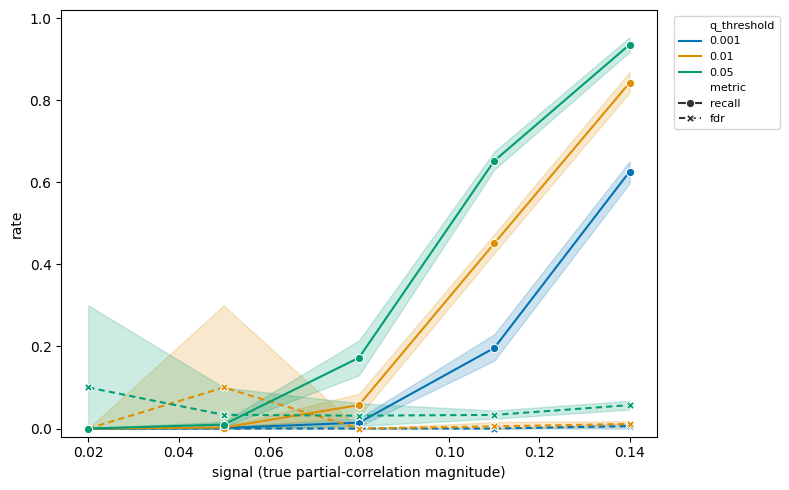

In [5]:
# Plot recall (solid) and FDR (dashed) vs. signal, one color per q-threshold.
# Seaborn aggregates across runs: line = mean across runs, band = 95% bootstrap CI.
long_df = performance_df.melt(
    id_vars=['signal', 'q_threshold'],
    value_vars=['recall', 'fdr'],
    var_name='metric',
    value_name='rate',
)
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=long_df,
    x='signal',
    y='rate',
    hue='q_threshold',
    style='metric',
    style_order=['recall', 'fdr'],
    markers={'recall': 'o', 'fdr': 'X'},
    dashes={'recall': '', 'fdr': (3, 2)},
    palette='colorblind',
    errorbar=('ci', 95),
)
plt.xlabel('signal (true partial-correlation magnitude)')
plt.ylabel('rate')
plt.ylim(-0.02, 1.02)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()

save_fig(plt.gcf(), 'NetworkRecovery', CHAPTER, basedir=IMAGE_DIR)

plt.show()